# Blue Team: Multi-Source Incident Correlation

**Track:** Blue team / incident response

Fuse identity, endpoint, DNS, network, and cloud alerts into investigation-ready clusters.

> **Safety boundary:** This lab is an offline analytical simulation. It contains no payloads, credential collection, exploitation steps, delivery infrastructure, or instructions for targeting real systems.

## Goal

Evaluate a transparent time/entity correlation rule, benchmark ML classification, visualize a representative incident timeline, and create a ranked cluster queue.


## Setup

The notebook uses deterministic synthetic data, an inspectable baseline, held-out evaluation, and figures designed for GitHub preview. Metrics demonstrate the workflow—not production effectiveness.


In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

BLUE = "#2F6B9A"
GOLD = "#D39A2C"
ORANGE = "#D66B3D"
OLIVE = "#71834A"
PINK = "#B05A7A"
SLATE = "#566573"
PALETTE = [BLUE, GOLD, ORANGE, OLIVE, PINK, SLATE]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.18,
    "font.size": 9,
})

def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-np.clip(values, -30, 30)))

def model_metrics(labels, probabilities, threshold=0.5):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "average_precision": average_precision_score(labels, probabilities),
        "roc_auc": roc_auc_score(labels, probabilities),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "reviewed": int(predictions.sum()),
    }

def top_k_metrics(labels, probabilities, review_capacity):
    labels = np.asarray(labels)
    probabilities = np.asarray(probabilities)
    selected = np.argsort(probabilities)[-review_capacity:]
    predictions = np.zeros(len(probabilities), dtype=int)
    predictions[selected] = 1
    return {
        "average_precision": average_precision_score(labels, probabilities),
        "roc_auc": roc_auc_score(labels, probabilities),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "reviewed": int(predictions.sum()),
    }

def build_pipeline(numeric_features, categorical_features, estimator):
    transformer = ColumnTransformer([
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ])
    return Pipeline([("features", transformer), ("model", estimator)])

def feature_importance_table(pipeline):
    names = pipeline.named_steps["features"].get_feature_names_out()
    model = pipeline.named_steps["model"]
    values = (
        np.abs(model.coef_[0])
        if hasattr(model, "coef_")
        else model.feature_importances_
    )
    return (
        pd.DataFrame({"feature": names, "importance": values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


## Steps

### 1. Generate linked incident events and benign noise


In [2]:
sources = np.array(["Identity", "Endpoint", "DNS", "Network", "Cloud"])
phases = np.array(["Access", "Execution", "Discovery", "Movement", "Collection"])
event_rows = []
event_counter = 0

for incident_number in range(110):
    incident_id = f"INC-{incident_number:03d}"
    root_user = f"user-{rng.integers(0, 70):03d}"
    root_host = f"host-{rng.integers(0, 85):03d}"
    start_minute = int(rng.integers(0, 7 * 24 * 60))
    event_total = int(rng.integers(8, 16))
    for step in range(event_total):
        event_counter += 1
        phase_index = min(4, int(step / max(event_total - 1, 1) * 5))
        source = rng.choice(sources, p=[0.23, 0.28, 0.17, 0.18, 0.14])
        event_rows.append({
            "event_id": f"EVT-{event_counter:05d}",
            "incident_id": incident_id,
            "time_minute": start_minute + int(step * rng.integers(3, 10) + rng.integers(0, 4)),
            "user_id": root_user,
            "host_id": root_host if rng.random() < 0.78 else f"host-{rng.integers(0, 85):03d}",
            "source": source,
            "phase": phases[phase_index],
            "severity": int(rng.integers(2, 6)),
            "rarity": rng.beta(2.8, 1.5),
            "rule_confidence": rng.beta(2.6, 1.6),
            "asset_criticality": int(rng.integers(2, 6)),
            "is_incident": 1,
        })

for _ in range(1700):
    event_counter += 1
    event_rows.append({
        "event_id": f"EVT-{event_counter:05d}",
        "incident_id": "BENIGN",
        "time_minute": int(rng.integers(0, 7 * 24 * 60)),
        "user_id": f"user-{rng.integers(0, 260):03d}",
        "host_id": f"host-{rng.integers(0, 320):03d}",
        "source": rng.choice(sources),
        "phase": "Routine",
        "severity": int(rng.integers(1, 5)),
        "rarity": rng.beta(1.2, 4.5),
        "rule_confidence": rng.beta(1.4, 3.8),
        "asset_criticality": int(rng.integers(1, 6)),
        "is_incident": 0,
    })

events = pd.DataFrame(event_rows).sort_values("time_minute").reset_index(drop=True)
events["hour"] = events["time_minute"] / 60
print(f"Synthetic events: {len(events):,}")
print(f"Linked incidents: {events.loc[events['is_incident'].eq(1), 'incident_id'].nunique():,}")
print(f"Incident-event prevalence: {events['is_incident'].mean():.1%}")
print(events.head(4).to_string(index=False))


Synthetic events: 2,913
Linked incidents: 110
Incident-event prevalence: 41.6%
 event_id incident_id  time_minute  user_id  host_id   source   phase  severity   rarity  rule_confidence  asset_criticality  is_incident     hour
EVT-00331     INC-031            5 user-044 host-033 Identity  Access         3 0.623604         0.651550                  3            1 0.083333
EVT-00332     INC-031            7 user-044 host-033    Cloud  Access         2 0.851000         0.672734                  2            1 0.116667
EVT-01366      BENIGN           13 user-084 host-036 Identity Routine         1 0.059248         0.160058                  5            0 0.216667
EVT-01304      BENIGN           15 user-130 host-226  Network Routine         3 0.194986         0.294339                  3            0 0.250000


### 2. Correlate by entity, time window, and source diversity


In [3]:
events["window_30m"] = (events["time_minute"] // 30).astype(int)
events["correlation_key"] = events["user_id"] + "|" + events["window_30m"].astype(str)
cluster_features = events.groupby("correlation_key").agg(
    event_count=("event_id", "count"),
    source_count=("source", "nunique"),
    host_count=("host_id", "nunique"),
    max_severity=("severity", "max"),
    mean_rarity=("rarity", "mean"),
    max_rule_confidence=("rule_confidence", "max"),
    incident_events=("is_incident", "sum"),
)
events = events.join(cluster_features, on="correlation_key", rsuffix="_cluster")
events["baseline_correlated"] = (
    (events["event_count"] >= 3) & (events["source_count"] >= 2)
    & (events["max_severity"] >= 4)
).astype(int)
baseline_probability = np.clip(
    0.18 * (events["event_count"] / events["event_count"].clip(lower=1).quantile(0.95))
    + 0.24 * (events["source_count"] / 5)
    + 0.12 * (events["host_count"] / events["host_count"].clip(lower=1).quantile(0.95))
    + 0.16 * (events["max_severity"] / 5)
    + 0.16 * events["mean_rarity"]
    + 0.14 * events["max_rule_confidence"], 0, 1,
)
baseline_result = model_metrics(events["is_incident"], baseline_probability, 0.52)
cluster_queue = cluster_features.assign(
    incident_share=lambda frame: frame["incident_events"] / frame["event_count"],
    triage_score=lambda frame: (
        frame["source_count"] * 2 + frame["max_severity"] + frame["mean_rarity"] * 3
        + frame["max_rule_confidence"] * 2
    ),
).sort_values("triage_score", ascending=False).head(12)
print("Baseline event-level quality:")
print(pd.Series(baseline_result).round(3).to_string())
print("\nTop correlated clusters:")
print(cluster_queue.round(3).to_string())


Baseline event-level quality:
average_precision       0.985
roc_auc                 0.996
precision               0.995
recall                  0.890
f1                      0.940
reviewed             1085.000

Top correlated clusters:
                 event_count  source_count  host_count  max_severity  mean_rarity  max_rule_confidence  incident_events  incident_share  triage_score
correlation_key                                                                                                                                      
user-028|191               6             5           2             5        0.876                0.978                6           1.000        19.585
user-018|70                6             5           4             5        0.806                0.852                6           1.000        19.123
user-006|221               5             5           1             5        0.704                0.882                5           1.000        18.876
user-019|114  

## Visual Insights & ML Extension

A representative timeline preserves event order, while source/phase coverage, held-out quality, and global feature importance support triage and detection-engineering decisions.


                      average_precision  roc_auc  precision  recall     f1  reviewed
model                                                                               
Correlation baseline              0.987    0.997      0.997   0.931  0.963       354
Logistic                          0.998    0.998      0.969   0.992  0.980       388
Random forest                     0.999    0.999      0.979   0.989  0.984       383

Decision insight: source diversity and temporal/entity density help turn isolated alerts into investigation context.


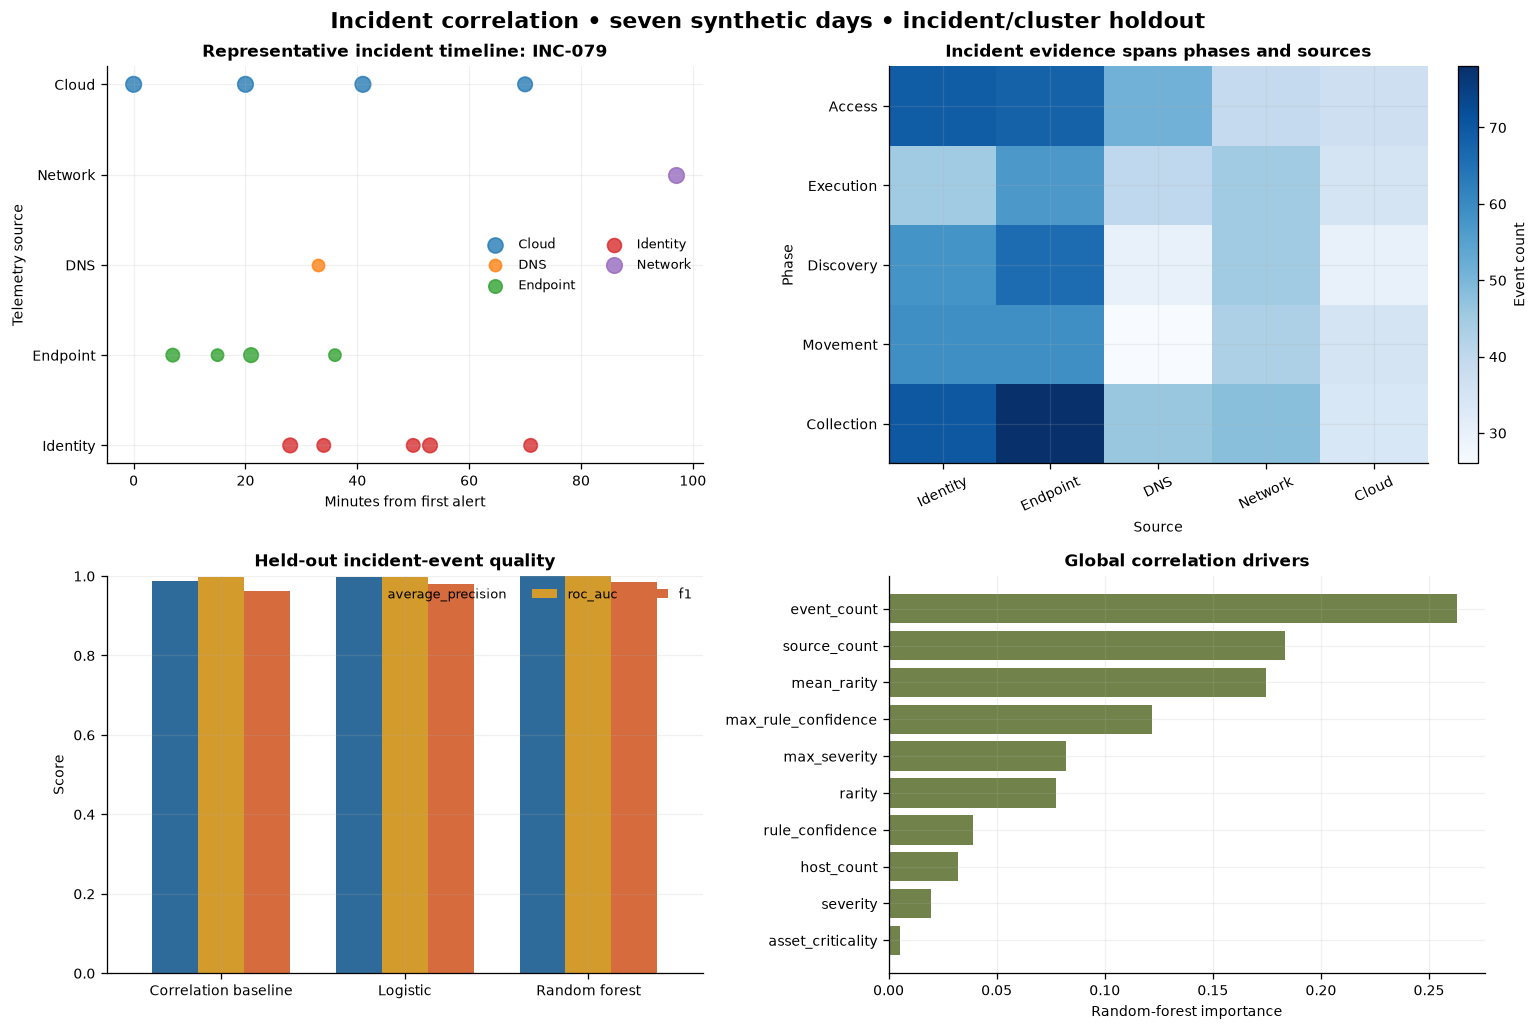

In [4]:
feature_columns = [
    "source", "severity", "rarity", "rule_confidence", "asset_criticality",
    "event_count", "source_count", "host_count", "max_severity",
    "mean_rarity", "max_rule_confidence",
]
categorical_features = ["source"]
numeric_features = [column for column in feature_columns if column not in categorical_features]
split_groups = np.where(
    events["is_incident"].eq(1),
    events["incident_id"],
    "BENIGN|" + events["correlation_key"],
)
group_split = GroupShuffleSplit(n_splits=1, test_size=0.28, random_state=SEED)
train_index, test_index = next(group_split.split(events, events["is_incident"], groups=split_groups))
X_train = events.loc[train_index, feature_columns]
X_test = events.loc[test_index, feature_columns]
y_train = events.loc[train_index, "is_incident"]
y_test = events.loc[test_index, "is_incident"]
logistic = build_pipeline(numeric_features, categorical_features,
                          LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED))
forest = build_pipeline(numeric_features, categorical_features,
                        RandomForestClassifier(n_estimators=260, min_samples_leaf=6, class_weight="balanced", random_state=SEED))
logistic.fit(X_train, y_train)
forest.fit(X_train, y_train)
probabilities = {
    "Correlation baseline": baseline_probability[test_index],
    "Logistic": logistic.predict_proba(X_test)[:, 1],
    "Random forest": forest.predict_proba(X_test)[:, 1],
}
metrics_table = pd.DataFrame([
    {"model": name, **model_metrics(y_test, values, 0.5)}
    for name, values in probabilities.items()
]).set_index("model")
importance = feature_importance_table(forest).head(10).sort_values("importance")

sample_incident_id = events.loc[events["is_incident"].eq(1), "incident_id"].value_counts().index[0]
timeline = events[events["incident_id"].eq(sample_incident_id)].sort_values("time_minute").copy()
timeline["relative_minute"] = timeline["time_minute"] - timeline["time_minute"].min()
source_positions = {source: index for index, source in enumerate(sources)}
coverage = pd.crosstab(
    events.loc[events["is_incident"].eq(1), "phase"],
    events.loc[events["is_incident"].eq(1), "source"],
).reindex(index=phases, columns=sources, fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.1))
for source_name, group in timeline.groupby("source"):
    axes[0, 0].scatter(group["relative_minute"], [source_positions[source_name]] * len(group),
                       s=35 + group["severity"] * 12, label=source_name, alpha=0.78)
axes[0, 0].set(title=f"Representative incident timeline: {sample_incident_id}", xlabel="Minutes from first alert",
               ylabel="Telemetry source", yticks=list(source_positions.values()), yticklabels=list(source_positions.keys()))
axes[0, 0].legend(frameon=False, ncol=2, fontsize=8)

image = axes[0, 1].imshow(coverage.values, cmap="Blues", aspect="auto")
axes[0, 1].set(title="Incident evidence spans phases and sources", xlabel="Source", ylabel="Phase",
               xticks=range(len(sources)), xticklabels=sources, yticks=range(len(phases)), yticklabels=phases)
axes[0, 1].tick_params(axis="x", rotation=25)
fig.colorbar(image, ax=axes[0, 1], fraction=0.046, label="Event count")

metrics_table[["average_precision", "roc_auc", "f1"]].plot(
    kind="bar", ax=axes[1, 0], color=[BLUE, GOLD, ORANGE], width=0.75
)
axes[1, 0].set(title="Held-out incident-event quality", xlabel="", ylabel="Score", ylim=(0, 1))
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].legend(frameon=False, ncol=3, fontsize=8)

axes[1, 1].barh(importance["feature"].str.replace("numeric__", "").str.replace("categorical__", ""),
                importance["importance"], color=OLIVE)
axes[1, 1].set(title="Global correlation drivers", xlabel="Random-forest importance")
fig.suptitle("Incident correlation • seven synthetic days • incident/cluster holdout", fontsize=14, fontweight="bold")
fig.tight_layout()

print(metrics_table.round(3).to_string())
print("\nDecision insight: source diversity and temporal/entity density help turn isolated alerts into investigation context.")


## Checks

Assertions verify event grain, incident linkage, correlation features, holdout separation, and bounded metrics.


In [5]:
assert events["event_id"].is_unique
assert events.isna().sum().sum() == 0
assert events.loc[events["is_incident"].eq(1), "incident_id"].ne("BENIGN").all()
assert events.loc[events["is_incident"].eq(0), "incident_id"].eq("BENIGN").all()
assert (events["source_count"] <= 5).all()
assert set(train_index).isdisjoint(set(test_index))
assert set(split_groups[train_index]).isdisjoint(set(split_groups[test_index]))
assert metrics_table[["average_precision", "roc_auc", "precision", "recall", "f1"]].apply(lambda column: column.between(0, 1).all()).all()
print("All checks passed: unique events, valid linkage, bounded source diversity, clean holdout, and bounded metrics.")


All checks passed: unique events, valid linkage, bounded source diversity, clean holdout, and bounded metrics.


## Next Steps

- Replace synthetic events with approved normalized telemetry and retain source event IDs for auditability.
- Extend the incident-level holdout into a forward time split to test drift and prevent look-ahead leakage.
- Add clock-skew handling, late-arriving evidence, entity-resolution confidence, and analyst feedback.
- Treat ML as triage support; preserve raw evidence and require human confirmation before containment.
